In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [2]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Dhanush"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language",name="Dhanush"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Dhanush

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Dhanush

I want to learn python programming language


In [3]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="gemma2-9b-it")
result=llm.invoke(messages)

In [4]:
result.response_metadata

{'token_usage': {'completion_tokens': 275,
  'prompt_tokens': 55,
  'total_tokens': 330,
  'completion_time': 0.5,
  'prompt_time': 0.001799381,
  'queue_time': 0.249016689,
  'total_time': 0.501799381},
 'model_name': 'gemma2-9b-it',
 'system_fingerprint': 'fp_10c08bf97d',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None}

In [5]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001385C955E80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001385CC6E8A0>, model_name='gemma2-9b-it', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
def add(a: int, b: int) -> int:
    """Add two integers."""
    return a + b

In [10]:
#Binding with llm model
llm_with_tools = llm.bind_tools([add])
tool_call = llm_with_tools.invoke([HumanMessage(content = "What is 2+2?" , name = "Dhanush")])


In [12]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': '73h92feam',
  'type': 'tool_call'}]

In [14]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    """State for the tool call."""
    tool_calls: list[AnyMessage]
    """List of tool calls made during the invocation."""

In [18]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]



In [20]:
from langchain_core.messages import HumanMessage, AIMessage

intial_messages = [HumanMessage(content="Hello, How are you?", name="User")]
intial_messages.append(AIMessage(content="I am fine, How can I help you?", name="LLMModel"))
intial_messages

[HumanMessage(content='Hello, How are you?', additional_kwargs={}, response_metadata={}, name='User'),
 AIMessage(content='I am fine, How can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel')]

In [22]:
ai_messages = [AIMessage(content = "I am fine , How can i help you?" , name = "LLmModel")]
ai_messages


[AIMessage(content='I am fine , How can i help you?', additional_kwargs={}, response_metadata={}, name='LLmModel')]

In [23]:
add_messages = [intial_messages, ai_messages]

In [27]:
def llm_tool(state:State):
    return {message:[llm_with_tools.invoke(state["messages"])]}
    


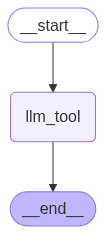

In [32]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




In [36]:
def llm_tool(state: State):
    # Get the current messages
    messages = state["messages"]
    # Get the LLM response (should be an AIMessage)
    response = llm_with_tools.invoke(messages)
    # Return the updated state with the new message appended
    return {"messages": messages + [response]}

In [1]:
messages = graph.invoke({"messages": [HumanMessage(content="What is 2 plus 2", name="Dhanush")]})

for message in messages["messages"]:
    message.pretty_print()

NameError: name 'graph' is not defined

In [ ]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder=StateGraph(State)

## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


graph_builder = builder.compile()

NameError: name 'tool' is not defined